# AnimalCLEF 2026 — DINOv2 Re-ID Pipeline
Fine-tunes ViT-Base/16 (DINOv2) with ArcFace loss on known identities,
then uses MLS thresholding for open-set detection and DBSCAN for unknown individual clustering.

In [2]:
!pip install wildlife-datasets git+https://github.com/WildlifeDatasets/wildlife-tools --quiet --upgrade-strategy only-if-needed

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
ROOT  = '/content/drive/My Drive/dl_finalproject_animalclef'

ModuleNotFoundError: No module named 'google.colab'

In [40]:
ROOT= '../'

In [41]:
import shutil, os
import warnings
warnings.filterwarnings('ignore')
import os

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm

from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances

In [ ]:
LOCAL_ROOT = '/content/animalCLEF-2026/'

if not os.path.exists(LOCAL_ROOT):
    os.makedirs(LOCAL_ROOT, exist_ok=True)
    items_to_copy = ['images', 'sample_submission.csv', 'metadata.csv']
    for item in items_to_copy:
        src = os.path.join(ROOT, item)
        dst = os.path.join(LOCAL_ROOT, item)
        if os.path.isdir(src):
            print(f'Copying {src} → {dst} ...')
            shutil.copytree(src, dst)
        elif os.path.isfile(src):
            print(f'Copying {src} → {dst} ...')
            shutil.copy2(src, dst)
        else:
            print(f'WARNING: {src} not found, skipping.')
    print('Done.')
else:
    print('Local data already exists, skipping copy.')

# Switch ROOT to local SSD for fast I/O
ROOT = LOCAL_ROOT
print('Using ROOT:', ROOT)

code starts here

In [85]:
import torch

CFG = dict(
    model_name        = 'vit_base_patch16_224.dino',
    img_size          = 224,
    embed_dim         = 512,      # ViT-Base output dim; set smaller (e.g. 512) to project down
    arcface_s         = 16.0,     # scale
    arcface_m         = 0.35,     # margin
    batch_size        = 32,
    num_epochs        = 30,
    lr_head           = 1e-3,     # head + projector LR during warmup
    lr_backbone       = 2e-5,     # last 4 ViT blocks LR during fine-tune
    warmup_epochs     = 3,        # freeze backbone for this many epochs first
    mls_threshold     = None,     # auto-calibrated from train MLS distribution
    mls_pct           = 5,        # percentile of train MLS used as threshold
    dbscan_eps        = 0.5,      # cosine distance cutoff for DBSCAN
    dbscan_min_samples= 2,
    device = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'),
    seed              = 42,
    unfrozen_blocks   = 4,
    weight_decay  = 5e-4,
)
torch.manual_seed(CFG['seed'])
np.random.seed(CFG['seed'])
print('Device:', CFG['device'])

Device: mps


In [86]:
print(CFG['mls_threshold']) 

None


wanbd login

In [ ]:
import wandb

wandb.login()

run = wandb.init(
    project='animalCLEF-2026',
    name=f'dinov2_{CFG["model_name"]}_s{CFG["arcface_s"]}_m{CFG["arcface_m"]}',
    config=CFG,
)
print(f'wandb run: {run.url}')

## 1. Data Loading

In [74]:
meta = pd.read_csv(os.path.join(ROOT, 'metadata.csv'))
print(meta.groupby(['dataset', 'split']).size().to_string())
print(f"\nTotal images: {len(meta)}")
print(f"Unknown (no identity label): {meta['identity'].isna().sum()}")

dataset             split
LynxID2025          test      946
                    train    2957
SalamanderID2025    test      689
                    train    1388
SeaTurtleID2022     test      500
                    train    8729
TexasHornedLizards  test      274

Total images: 15483
Unknown (no identity label): 2409


In [75]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit

meta = pd.read_csv(os.path.join(ROOT, 'metadata.csv'))

# All training images with known identity labels
all_train_df = meta[(meta['split'] == 'train') & (meta['identity'].notna())].copy()
query_df     = meta[meta['split'] == 'test'].copy()

# Split by identity group: ~15% of identities go to val (their images are "novel" to the model)
gss = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=CFG['seed'])
train_idx, val_idx = next(gss.split(all_train_df, groups=all_train_df['identity']))
train_meta = all_train_df.iloc[train_idx].reset_index(drop=True)
val_meta   = all_train_df.iloc[val_idx].reset_index(drop=True)

# Fit LabelEncoder on train identities only
le = LabelEncoder()
le.fit(train_meta['identity'].values)

NUM_CLASSES = len(le.classes_)
print(f'Known identities (train classes): {NUM_CLASSES}')
print(f'Train images : {len(train_meta)}')
print(f'Val images   : {len(val_meta)}  ({val_meta["identity"].nunique()} novel identities)')
print(f'Query images : {len(query_df)}')

Known identities (train classes): 936
Train images : 11578
Val images   : 1496  (166 novel identities)
Query images : 2409


In [76]:
CKPT_DIR = os.path.join(ROOT, 'checkpoints/dinov2/')
os.makedirs(CKPT_DIR, exist_ok=True)

def save_checkpoint(model, epoch, loss, acc, tag='last'):
    path = os.path.join(CKPT_DIR, f'dinov2_{epoch}.pt')
    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'le': le,
        'cfg': CFG,
        'loss': loss,
        'acc': acc,
    }, path)
    return path

In [77]:
class TrainDataset(Dataset):
    """Returns (image_tensor, integer_label) for ArcFace training."""
    def __init__(self, metadata: pd.DataFrame, le: LabelEncoder,
                 transform, root: str):
        self.paths     = metadata['path'].values
        self.labels    = le.transform(metadata['identity'].values)
        self.transform = transform
        self.root      = root
        self.le        = le

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.paths[idx])).convert('RGB')
        return self.transform(img), self.labels[idx]

    @property
    def num_classes(self):
        return len(self.le.classes_)


class ValDataset(Dataset):
    """
    Returns (image_tensor, identity_string) for open-set evaluation.
    Contains a mix of known individuals (identity in train) and novel
    individuals (identity never seen in training).
    """
    def __init__(self, metadata: pd.DataFrame, transform, root: str):
        self.paths      = metadata['path'].values
        self.identities = metadata['identity'].fillna('unknown').values
        self.transform  = transform
        self.root       = root

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(os.path.join(self.root, self.paths[idx])).convert('RGB')
        return self.transform(img), self.identities[idx]


size = CFG['img_size']
mean, std = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((size, size)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.ToTensor(),
    T.Normalize(mean, std),
])
val_tf = T.Compose([
    T.Resize((size, size)),
    T.ToTensor(),
    T.Normalize(mean, std),
])

num_workers = 0  # 0 for Colab; set to 4 for local

train_ds  = TrainDataset(train_meta, le, train_tf, ROOT)
val_ds    = ValDataset(val_meta,         val_tf,   ROOT)
query_ds  = ValDataset(query_df,         val_tf,   ROOT)

train_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=True,
                          num_workers=num_workers, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=num_workers)
query_loader = DataLoader(query_ds, batch_size=64, shuffle=False, num_workers=num_workers)

print(f'Train batches: {len(train_loader)}  |  Val batches: {len(val_loader)}  |  Query batches: {len(query_loader)}')

Train batches: 361  |  Val batches: 24  |  Query batches: 38


## 2. Model — DINOv2 ViT-Base + ArcFace Head

loss function

In [78]:
class ArcFaceLoss(nn.Module):
    """Additive Angular Margin Loss.
    Adds a fixed margin to the target class angle before softmax,
    pushing intra-class embeddings together and inter-class apart.
    """
    def __init__(self, in_features, num_classes, s=30.0, m=0.50):
        super().__init__()
        self.s, self.m = s, m
        self.weight = nn.Parameter(torch.FloatTensor(num_classes, in_features))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(m)
        self.sin_m = math.sin(m)
        self.th = math.cos(math.pi - m)
        self.mm = math.sin(math.pi - m) * m

    def forward(self, emb, labels):
        cosine = F.linear(F.normalize(emb), F.normalize(self.weight))  # (B, C)
        sine   = (1.0 - cosine.pow(2)).clamp(0, 1).sqrt()
        phi    = cosine * self.cos_m - sine * self.sin_m  # cos(theta + margin)
        phi    = torch.where(cosine > self.th, phi, cosine - self.mm)
        one_hot = torch.zeros_like(cosine).scatter_(1, labels.view(-1, 1), 1.0)
        logits  = (one_hot * phi + (1.0 - one_hot) * cosine) * self.s
        return F.cross_entropy(logits, labels, label_smoothing=0.1), logits

In [95]:
class DINOv2ReID(nn.Module):
    def __init__(self, model_name, embed_dim, num_classes, s, m):
        super().__init__()
        # num_classes=0, backbone returns raw [CLS] token embedding
        self.backbone = timm.create_model(model_name, pretrained=True, num_classes=0)
        bb_dim = self.backbone.num_features  # 768 for ViT-Base
        # Optional linear projection; keeps dim if embed_dim == bb_dim
        self.projector = (
            nn.Sequential(nn.Linear(bb_dim, embed_dim), nn.BatchNorm1d(embed_dim))
            if embed_dim != bb_dim else nn.Identity()
        )
        self.arcface = ArcFaceLoss(embed_dim, num_classes, s=s, m=m)

    def embed(self, x):
        """Return L2-normalised embedding (used at inference)."""
        return F.normalize(self.projector(self.backbone(x)), dim=1)

    def forward(self, x, labels=None):
        emb = self.embed(x)
        if labels is not None:
            loss, logits = self.arcface(emb, labels)
            return loss, logits, emb
        return emb

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_last_blocks(self, n=4):
        for p in self.backbone.parameters():
            p.requires_grad = False
        for block in list(self.backbone.blocks)[-n:]:
            for p in block.parameters():
                p.requires_grad = True
        for p in self.backbone.norm.parameters():
            p.requires_grad = True


model = DINOv2ReID(
    model_name=CFG['model_name'],
    embed_dim=CFG['embed_dim'],
    num_classes=NUM_CLASSES,
    s=CFG['arcface_s'],
    m=CFG['arcface_m'],                           
).to(CFG['device'])

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f'Total params: {total_params:.1f}M')

Total params: 86.7M


## 3. Training

In [94]:
@torch.no_grad()
def extract_val_embeddings(model, loader, device):
    model.eval()
    embs, identities = [], []
    for imgs, ids in loader:
        emb = model.embed(imgs.to(device))
        embs.append(emb.cpu())
        identities.extend(ids)
    return torch.cat(embs).numpy(), np.array(identities)

def rank1_accuracy(embs, identities):
    normed = embs / np.linalg.norm(embs, axis=1, keepdims=True)
    sim = normed @ normed.T
    np.fill_diagonal(sim, -np.inf)
    pred_ids = identities[sim.argmax(axis=1)]
    return (pred_ids == identities).mean()

def make_optimizer(model, phase):
    if phase == 'warmup':
        model.freeze_backbone()
        params = [
            {'params': model.projector.parameters(), 'lr': CFG['lr_head']},
            {'params': model.arcface.parameters(),   'lr': CFG['lr_head']},
        ]
    else:  # finetune
        model.unfreeze_last_blocks(n=CFG['unfrozen_blocks'])
        params = [
            {'params': [p for p in model.backbone.parameters() if p.requires_grad],
             'lr': CFG['lr_backbone']},
            {'params': model.projector.parameters(), 'lr': CFG['lr_head']},
            {'params': model.arcface.parameters(),   'lr': CFG['lr_head']},
        ]
    return torch.optim.AdamW(params, weight_decay=CFG['weight_decay'])


def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total_loss, correct, n = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        loss, _, emb = model(imgs, labels)
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            cosine_logits = F.linear(F.normalize(emb.detach()),
                                     F.normalize(model.arcface.weight))
        total_loss += loss.item() * imgs.size(0)
        correct    += (cosine_logits.argmax(1) == labels).sum().item()
        n          += imgs.size(0)
    return total_loss / n, correct / n


history  = []
best_r1  = 0.0
optimizer = make_optimizer(model, 'warmup')
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=CFG['num_epochs'], eta_min=1e-6
)

for epoch in range(1, CFG['num_epochs'] + 1):
    if epoch == CFG['warmup_epochs'] + 1:
        n_blocks = CFG['unfrozen_blocks']
        print(f'--- Switching to backbone fine-tuning (last {n_blocks} blocks) ---')
        optimizer = make_optimizer(model, 'finetune')

    loss, acc = train_one_epoch(model, train_loader, optimizer, CFG['device'])
    scheduler.step()

    val_embs, val_ids = extract_val_embeddings(model, val_loader, CFG['device'])
    r1 = rank1_accuracy(val_embs, val_ids)

    history.append({'epoch': epoch, 'loss': loss, 'acc': acc, 'val_rank1': r1})
    log = {'epoch': epoch, 'train/loss': loss, 'train/acc': acc,
           'val/rank1': r1, 'lr': scheduler.get_last_lr()[0]}

    print(f'Epoch {epoch:02d}/{CFG["num_epochs"]}  loss={loss:.4f}  train_acc={acc:.4f}  val_rank1={r1:.4f}', end='')

    if r1 > best_r1:
        best_r1 = r1
        path = save_checkpoint(model, epoch, loss, acc, tag='best')
        log['best_val_rank1'] = best_r1
        print(f'  [best] saved {path}', end='')

    if epoch % 5 == 0 or epoch == CFG['num_epochs']:
        save_checkpoint(model, epoch, loss, acc, tag=f'epoch{epoch:02d}')

    print()
    wandb.log(log)

wandb.finish()


KeyboardInterrupt: 

In [ ]:
hist_df = pd.DataFrame(history)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].plot(hist_df['epoch'], hist_df['loss']);      axes[0].set(title='Loss',          xlabel='Epoch')
axes[1].plot(hist_df['epoch'], hist_df['acc']);       axes[1].set(title='Train Accuracy', xlabel='Epoch')
axes[2].plot(hist_df['epoch'], hist_df['val_rank1']); axes[2].set(title='Val Rank-1',     xlabel='Epoch')
plt.tight_layout(); plt.show()


LOAD PREVIOUS CHECKPOINT

In [93]:
# Load the saved model checkpoint
ckpt_path = os.path.join(ROOT, 'checkpoints/dinov2/dinov2_7.pt')
checkpoint = torch.load(ckpt_path, map_location=CFG['device'], weights_only=False)

# Recreate the model with saved config
model_cfg = checkpoint['cfg']
model = DINOv2ReID(
    model_name=model_cfg['model_name'],
    embed_dim=model_cfg['embed_dim'],
    num_classes=len(checkpoint['le'].classes_),
    s=model_cfg['arcface_s'],
    m=model_cfg['arcface_m'],
).to(CFG['device'])

# Load the state dict
model.load_state_dict(checkpoint['model_state'])
model.eval()

# Recreate label encoder if needed for mapping
le = checkpoint['le']
idx_to_class = {i: cls for i, cls in enumerate(le.classes_)}

print(f'Loaded model from {ckpt_path}')

Loaded model from ../checkpoints/dinov2/dinov2_7.pt


## 5. Open-Set Detection via MLS

In [ ]:
@torch.no_grad()
def extract_features(model, loader, device):
    """Returns (embeddings, raw_cosine_logits, labels) as numpy arrays."""
    model.eval()
    embs, logits_all, labels_all = [], [], []
    for imgs, labels in loader:
        imgs  = imgs.to(device)
        emb   = model.embed(imgs)                                           # (B, D)
        # Raw cosine logits — no margin, used for MLS scoring
        logit = F.linear(emb, F.normalize(model.arcface.weight))            # (B, C)
        embs.append(emb.cpu())
        logits_all.append(logit.cpu())
        # labels may be a tensor (TrainDataset) or tuple of strings (ValDataset)
        if isinstance(labels, torch.Tensor):
            labels_all.append(labels)
        else:
            labels_all.extend(labels)
    embs_np   = torch.cat(embs).numpy()
    logits_np = torch.cat(logits_all).numpy()
    labels_np = torch.cat(labels_all).numpy() if isinstance(labels_all[0], torch.Tensor) else np.array(labels_all)
    return embs_np, logits_np, labels_np


print('Extracting train embeddings...')
train_embs, train_logits, train_labels = extract_features(model, train_loader, CFG['device'])

print('Extracting query embeddings...')
query_embs, query_logits, query_labels = extract_features(model, query_loader, CFG['device'])

print(f'train_embs : {train_embs.shape}')
print(f'query_embs : {query_embs.shape}')

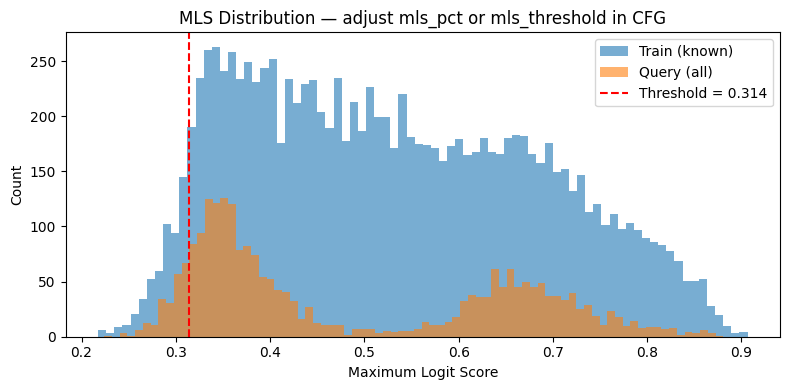

In [96]:
# ── Maximum Logit Score (MLS) ─────────────────────────────────────────────────
# High MLS = the model is confident this is a known individual.
# Low MLS  = likely an unknown individual from an unseen species.

train_mls = train_logits.max(axis=1)  # (N_train,)
query_mls = query_logits.max(axis=1)  # (N_query,)

# Calibrate from the training distribution.
# Lower percentile = more permissive (fewer unknowns flagged).
if CFG['mls_threshold'] is None:
    CFG['mls_threshold'] = float(np.percentile(train_mls, CFG['mls_pct']))
    print(f'Auto MLS threshold ({CFG["mls_pct"]}th pct of train MLS): {CFG["mls_threshold"]:.4f}')

plt.figure(figsize=(8, 4))
plt.hist(train_mls, bins=80, alpha=0.6, label='Train (known)')
plt.hist(query_mls, bins=80, alpha=0.6, label='Query (all)')
plt.axvline(CFG['mls_threshold'], color='red', linestyle='--',
            label=f'Threshold = {CFG["mls_threshold"]:.3f}')
plt.xlabel('Maximum Logit Score'); plt.ylabel('Count')
plt.legend(); plt.title('MLS Distribution — adjust mls_pct or mls_threshold in CFG')
plt.tight_layout(); plt.show()

In [97]:
# ── DBSCAN in cosine-distance space ──────────────────────────────────────────
unknown_mask = ~is_known
unknown_embs = query_embs[unknown_mask]

if unknown_embs.shape[0] > 0:
    dist_matrix = pairwise_distances(unknown_embs, metric='cosine')
    db = DBSCAN(
        eps=CFG['dbscan_eps'],
        min_samples=CFG['dbscan_min_samples'],
        metric='precomputed',
    ).fit(dist_matrix)

    cluster_labels = db.labels_
    n_clusters = len(set(cluster_labels) - {-1})
    n_noise    = (cluster_labels == -1).sum()
    print(f'DBSCAN clusters: {n_clusters}  |  noise singletons: {n_noise}')

    unknown_indices = np.where(unknown_mask)[0]
    dataset_col     = query_df['dataset'].values  # e.g. 'LynxID2025', 'SeaTurtleID2022'

    dataset_counters = {}  # tracks next free index per dataset
    cluster_to_id    = {}  # maps DBSCAN cluster label → assigned identity string

    for idx, cl in zip(unknown_indices, cluster_labels):
        dataset = dataset_col[idx]
        if cl == -1:
            # Singleton: unique ID for this image within its dataset
            n = dataset_counters.get(dataset, 0)
            predicted_ids[idx] = f'{dataset}_unknown_{n}'
            dataset_counters[dataset] = n + 1
        else:
            # Cluster: all images in this group share the same ID
            if cl not in cluster_to_id:
                n = dataset_counters.get(dataset, 0)
                cluster_to_id[cl] = f'{dataset}_unknown_{n}'
                dataset_counters[dataset] = n + 1
            predicted_ids[idx] = cluster_to_id[cl]
else:
    print('No unknown samples detected — lower mls_threshold if unexpected.')

DBSCAN clusters: 4  |  noise singletons: 3


## 6. Unknown Individual Clustering via DBSCAN

In [102]:
import re

def clean_cluster_id(pid):
    """Normalize identity strings to dataset_number format.
    e.g. LynxID2025_lynx_25 -> LynxID2025_25
         SeaTurtleID2022_t323 -> SeaTurtleID2022_323
         SalamanderID2025_131 -> SalamanderID2025_131 (unchanged)
         unknown_cluster_0   -> unknown_cluster_0 (unchanged)
    """
    m = re.match(r'^([A-Za-z]+\d+)_.*?(\d+)$', pid)
    if m:
        return f'{m.group(1)}_{m.group(2)}'
    return pid

submission = query_df[['image_id']].copy()
submission['cluster'] = ['cluster_' + clean_cluster_id(pid) for pid in predicted_ids]

print(submission['cluster'].value_counts().head(20))
print(f'\nTotal rows: {len(submission)}')

out_path = os.path.join(ROOT, 'submission_dinov2_7.csv')
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

cluster
cluster_LynxID2025_49           231
cluster_LynxID2025_62           214
cluster_LynxID2025_43           192
cluster_LynxID2025_05           159
cluster_SalamanderID2025_0      105
cluster_SalamanderID2025_131     99
cluster_SalamanderID2025_12      95
cluster_SeaTurtleID2022_0        81
cluster_LynxID2025_74            70
cluster_SalamanderID2025_342     69
cluster_LynxID2025_32            62
cluster_LynxID2025_25            59
cluster_SalamanderID2025_32      55
cluster_SalamanderID2025_93      49
cluster_SalamanderID2025_337     43
cluster_SeaTurtleID2022_323      40
cluster_SalamanderID2025_10      38
cluster_SalamanderID2025_68      36
cluster_SeaTurtleID2022_217      29
cluster_LynxID2025_45            27
Name: count, dtype: int64

Total rows: 2409
Saved: ../submission_dinov2_7.csv


In [100]:
print(CFG['mls_threshold'])  # if not None, it's stale

0.3137331008911133


## 7. Submission

In [101]:
submission = query_df[['image_id']].copy()
submission['identity'] = predicted_ids

print(submission['identity'].value_counts().head(20))
print(f'\nTotal rows: {len(submission)}')

out_path = os.path.join(ROOT, 'submission_dinov2.csv')
submission.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

identity
LynxID2025_lynx_49            231
LynxID2025_lynx_62            214
LynxID2025_lynx_43            192
LynxID2025_lynx_05            159
SalamanderID2025_unknown_0    105
SalamanderID2025_131           99
SalamanderID2025_12            95
SeaTurtleID2022_unknown_0      81
LynxID2025_lynx_74             70
SalamanderID2025_342           69
LynxID2025_lynx_32             62
LynxID2025_lynx_25             59
SalamanderID2025_32            55
SalamanderID2025_93            49
SalamanderID2025_337           43
SeaTurtleID2022_t323           40
SalamanderID2025_10            38
SalamanderID2025_68            36
SeaTurtleID2022_t217           29
LynxID2025_lynx_45             27
Name: count, dtype: int64

Total rows: 2409
Saved: ../submission_dinov2.csv


In [ ]:
ckpt_path = os.path.join(ROOT, 'dinov2_reid.pt')
torch.save({
    'model_state': model.state_dict(),
    'class_to_idx': class_to_idx,
    'cfg': CFG,
}, ckpt_path)
print(f'Checkpoint saved: {ckpt_path}')